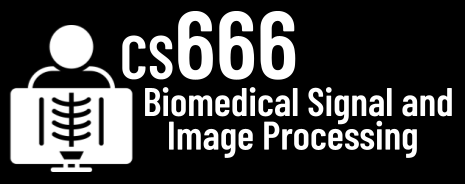
#Assignment 2

In [ ]:
### TODO: YOUR NAME
Yaozong Su

In [1]:
%pylab inline
import os

Populating the interactive namespace from numpy and matplotlib


In [2]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 28.4 MB/s eta 0:00:00


In [3]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [4]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m55s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [6]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
# TODO: YOUR ANSWER
eeg_ch = [ch for ch in raw.ch_names if ch.startswith('EEG')]
print("The number of EEG channels is: ", len(eeg_ch))

The number of EEG channels is:  60


In [7]:
raw.info

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

In [8]:
# TODO What is the sampling frequency of this data?
# TODO: YOUR ANSWER
print("The sampling freq is: ", raw.info['sfreq'])

The sampling freq is:  600.614990234375


In [9]:
# TODO What is the total duration of the measurement?
# TODO: YOUR ANSWER
print("The total duration: ", raw.times[-1])

The total duration:  277.7136813300495


In [10]:
raw.n_times/raw.info['sfreq']

np.float64(277.7153462901591)

**Task 2:** Let's look at some channels! [20 Points]

Using matplotlib as 2D backend.


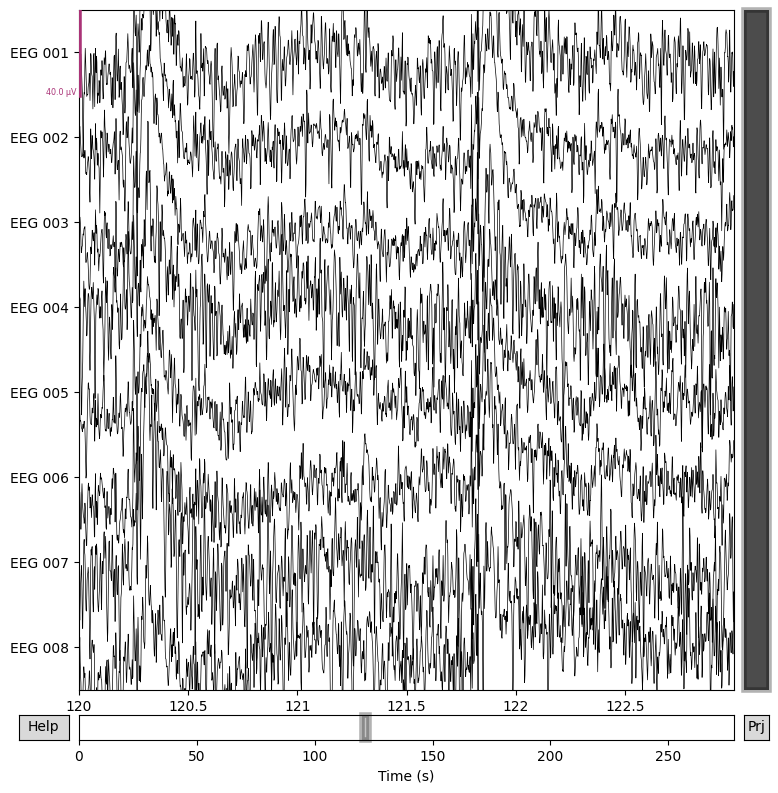

In [11]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

In [ ]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.

In [12]:
chs_50_60 = ['EEG {:03d}'.format(i) for i in range(50, 61)]
chs_50_60

['EEG 050',
 'EEG 051',
 'EEG 052',
 'EEG 053',
 'EEG 054',
 'EEG 055',
 'EEG 056',
 'EEG 057',
 'EEG 058',
 'EEG 059',
 'EEG 060']

In [13]:
chan_idxs = [raw.ch_names.index(ch) for ch in chs_50_60]
chan_idxs

[364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374]

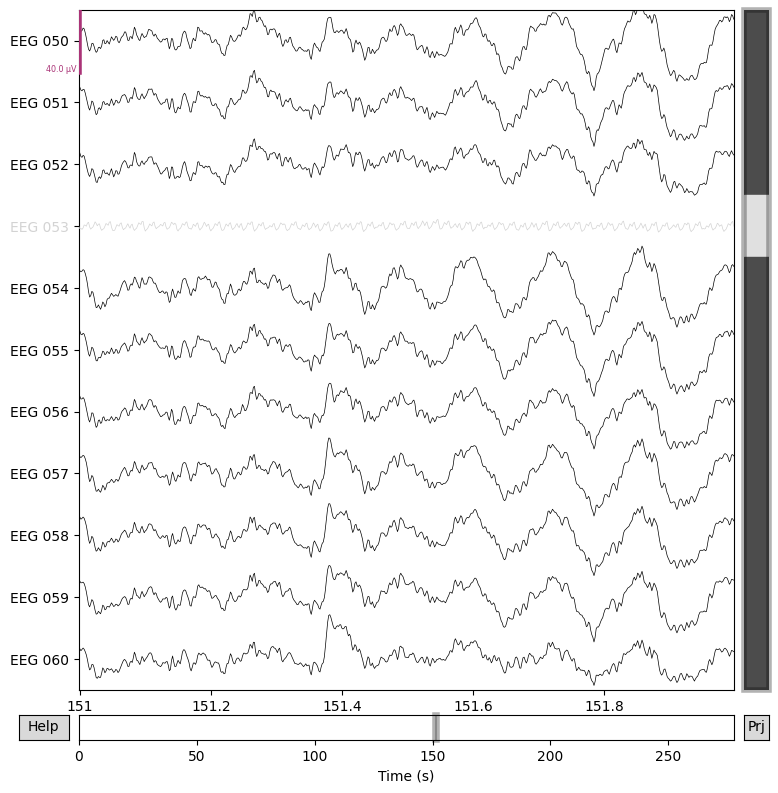

In [14]:
eeg_50to60 = raw.plot(order=chan_idxs, start=151, duration=1)

In [15]:
# TODO: Do you see a bad channel? If yes, which one?
# TODO: YOUR_ANSWER

Yes. There is a bad channel, 'EEG 053'.

In [ ]:
raw.info['bads']

['MEG 2443', 'EEG 053']

In [16]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels

In [17]:
bad_ch = 'EEG 053'
good_ch = 'EEG 056'
raw.get_data(picks=[bad_ch]).shape

(1, 166800)

In [18]:
bad_data = raw.get_data(picks=[bad_ch])[0]
good_data = raw.get_data(picks=[good_ch])[0]

In [19]:
max_bad = max(abs(bad_data))
max_good = max(abs(good_data))

print(f"Bad channel ({bad_ch}) max value: {max_bad:.6e}")
print(f"Good channel ({good_ch}) max value: {max_good:.6e}")

Bad channel (EEG 053) max value: 6.100562e-05
Good channel (EEG 056) max value: 1.539085e-04


Calculate the maximum value for each channel. This allows you to build a distribution of these metrics across all channels. Channels whose values are outliers can be considered as potential bad channels.

In [20]:
eeg_idxs = [raw.ch_names.index(ch) for ch in eeg_ch]
data = raw.get_data(picks=eeg_idxs)
max_vals = max(abs(data), axis=1)

In [21]:
import pandas as pd
df = pd.DataFrame({'channel': eeg_ch, 'max': max_vals})

In [22]:
stats = df['max'].describe()
Q1 = stats['25%']
Q3 = stats['75%']
IQR = Q3 - Q1
outliers = df[(df['max'] < Q1 - 1.5*IQR)]
print(outliers)

    channel       max
52  EEG 053  0.000061


**Task 3:** How long between event and brain activity? [25 Points]

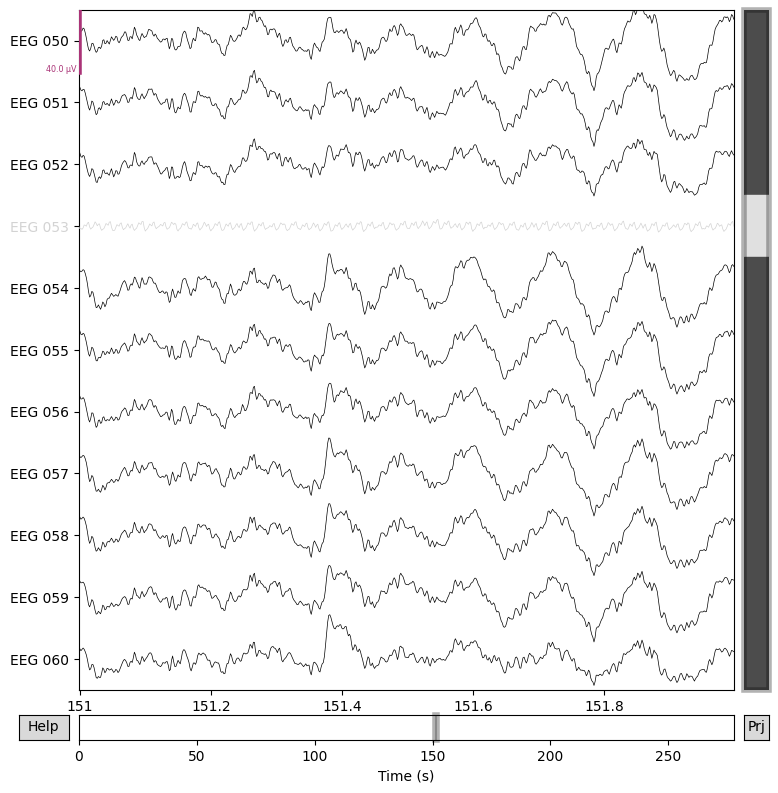

In [23]:
# the following code plots the stimulus channel for the same time
sti14_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [ ]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

In [24]:
stim014_idx = raw.ch_names.index('STI 014')

In [25]:
combined_idxs = chan_idxs + [stim014_idx]
print(combined_idxs)

[364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 312]


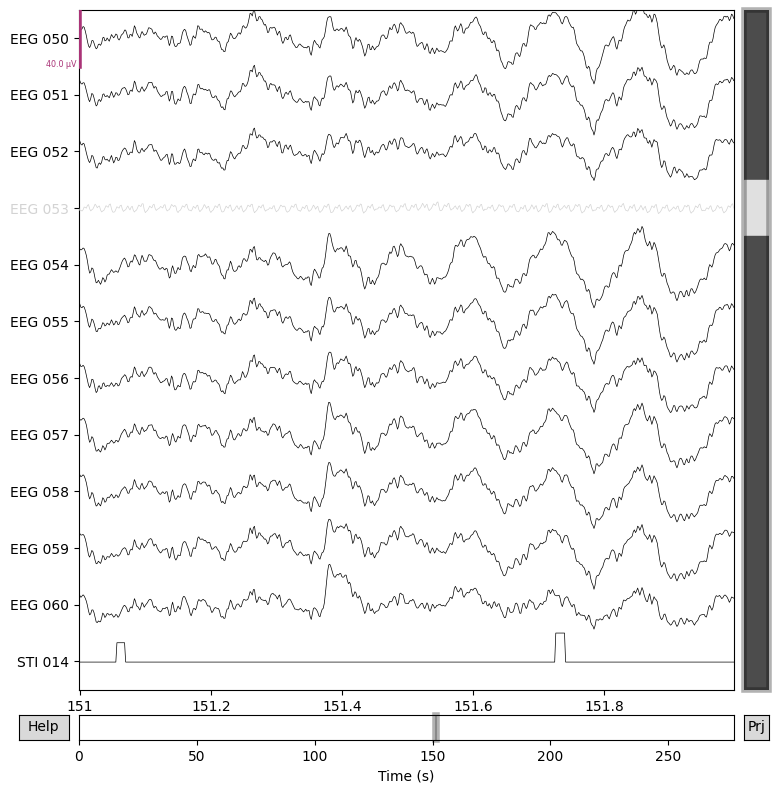

In [26]:
eeg50_60_stim014 = raw.plot(order=combined_idxs, start=151, duration=1)

In [ ]:
# TODO How many stimulus events do you observe?
# TODO: YOUR_ANSWER

There are 2 stimulus events.

In [ ]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# TODO: YOUR_ANSWER

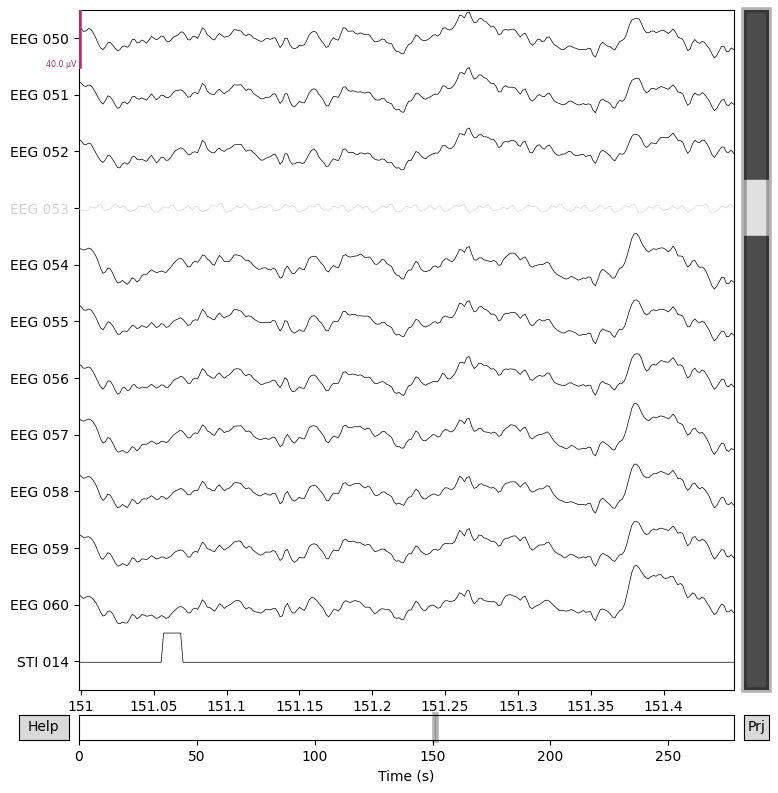

In [27]:
eeg50_60_stim014 = raw.plot(order=combined_idxs, start=151, duration=0.45)

In [ ]:
print("The estimated time: ",151.22 - 151.06)

The estimated time:  0.1599999999999966


**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [28]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


In [29]:
epochs

<Epochs | 320 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~63.6 MiB, data loaded,
 'auditory/left': 72
 'auditory/right': 73
 'visual/left': 73
 'visual/right': 71
 'face': 15
 'button': 16>

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


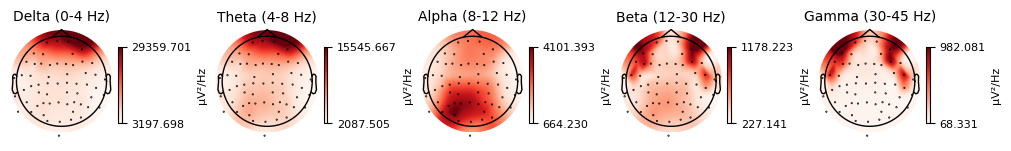

In [30]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


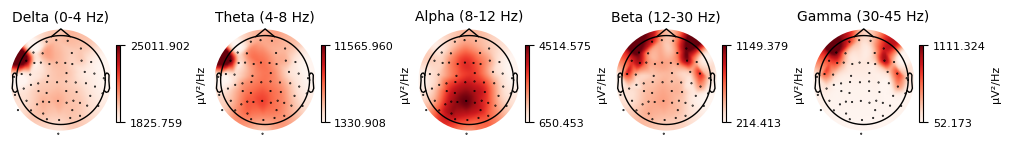

In [31]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

In [ ]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


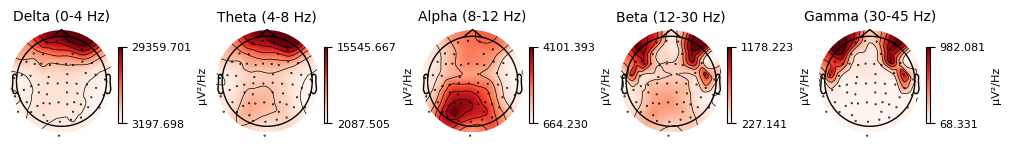

In [32]:
new_visual_activity = epochs['visual/right'].compute_psd().plot_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


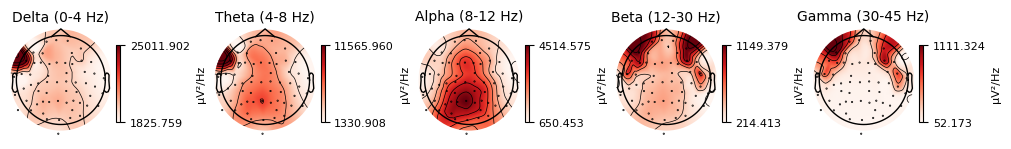

In [33]:
new_face_activity = epochs['face'].compute_psd().plot_topomap()

In [ ]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# TODO: YOUR ANSWER

The change is the addition of contour lines, which indicate areas with equal power levels, making spatial differences in brain activity easier to interpret.

In [ ]:
# TODO Please visualize the average brain activity when the subject pushes the button

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


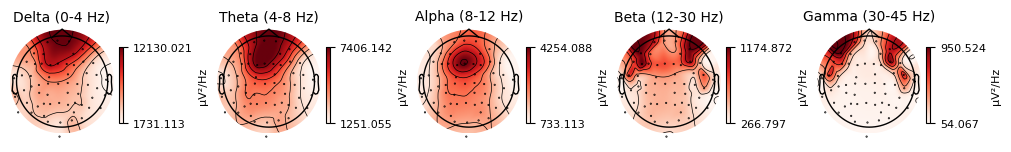

In [34]:
button_activity = epochs['button'].compute_psd().plot_topomap()

In [ ]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?
# TODO: YOUR ANSWER

Diff1: Delta/Theta waves
visual/right & button: activation in the upper frontal region;
face: activation in the upper left region.

Diff2: Alpha waves
visual/right & face: activation in the central-posterior region;
button: activation in the central-frontal region.

The brain region seems active during the button event: upper half of the scalp, because 'button' event is not only activation of the motor area, but a combined expression of visual processing, attention, and motor execution

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [ ]:
# TODO Please go back to Task 3. Can you figure out which event types happened?

In [35]:
sfreq = raw.info['sfreq']
window_start_sec = 151
window_duration_sec = 1

In [36]:
window_start_sample = int(window_start_sec * sfreq)
window_end_sample = int((window_start_sec + window_duration_sec) * sfreq)

events_in_window = events[(events[:,0] >= window_start_sample) & (events[:,0] <= window_end_sample)]

In [37]:
inv_event_dict = {v: k for k, v in event_dict.items()}
inv_event_dict

{1: 'auditory/left',
 2: 'auditory/right',
 3: 'visual/left',
 4: 'visual/right',
 5: 'face',
 32: 'button'}

In [38]:
event_names = [inv_event_dict[eid] for eid in events_in_window[:, 2]]
print("Event types: ", event_names)

Event types:  ['visual/right', 'auditory/right']


In [ ]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#